In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_dual_heatmaps(array1, array2, array3, 
                      title1='Heatmap 1', title2='Heatmap 2', title3='Heatmap 3',
                      cmap='viridis', figsize=(18, 6),
                      vmin=None, vmax=None,
                      colorbar=True, idx=0, text="training"):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)

    if vmin is None:
        vmin = min(np.nanmin(array1), np.nanmin(array2), np.nanmin(array3))
    if vmax is None:
        vmax = max(np.nanmax(array1), np.nanmax(array2), np.nanmin(array3))

    im1 = ax1.imshow(array1, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    ax1.set_title(title1)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    if colorbar:
        fig.colorbar(im1, ax=ax1, label='Value')

    im2 = ax2.imshow(array2, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    ax2.set_title(title2)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    if colorbar:
        fig.colorbar(im2, ax=ax2, label='Value')

    rmse = torch.mean((array2 - array3)**2).sqrt().item()

    im3 = ax3.imshow(array3, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    ax3.set_title(f"{title3} rmse={rmse:4f}")
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    if colorbar:
        fig.colorbar(im3, ax=ax3, label='Value')
    
    plt.suptitle(f"Navier-Stokes Vorticity Transport idx={idx} ({text})")
    plt.tight_layout()
    plt.show()

In [2]:
import os
import sys
from pathlib import Path

notebook_path = Path(os.getcwd())
project_root = notebook_path.parent.parent.parent
sys.path.append(str(project_root))

from models.FNO2d import FNO2d

# Load the data file
data_test = torch.load('../../../datasets/2D/NS/dim2d_nx256_N200_solver=exponax_kernel=matern_correlation_length0.50_bcperiodic_nu0.010_t40.0_seed5000.pt', weights_only=False)
data_train = torch.load('../../../datasets/2D/NS/dim2d_nx256_N5000_solver=exponax_kernel=matern_correlation_length0.50_bcperiodic_nu0.010_t40.0_seed0.pt', weights_only=False)
model_instance = FNO2d(
    modes1=128, 
    modes2=128, 
    width=32 
)
state_dict = torch.load(
    'NS_2d_FNO_model_trainedby_dim2d_nx256_N5000_solver=exponax_kernel=matern_correlation_length0.50_bcperiodic_nu0.010_t40.0_seed0.pth',
    map_location=torch.device('cpu')
)
model_instance.load_state_dict(state_dict)
model_instance.eval() 

FNO2d(
  (p): Linear(in_features=3, out_features=32, bias=True)
  (conv_layers): ModuleList(
    (0-3): 4 x SpectralConv2d()
  )
  (mlp_layers): ModuleList(
    (0-3): 4 x MLP(
      (mlp): Sequential(
        (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
      )
    )
  )
  (w_layers): ModuleList(
    (0-3): 4 x Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  )
  (q): MLP(
    (mlp): Sequential(
      (0): Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(128, 1, kernel_size=(1, 1), stride=(1, 1))
    )
  )
)

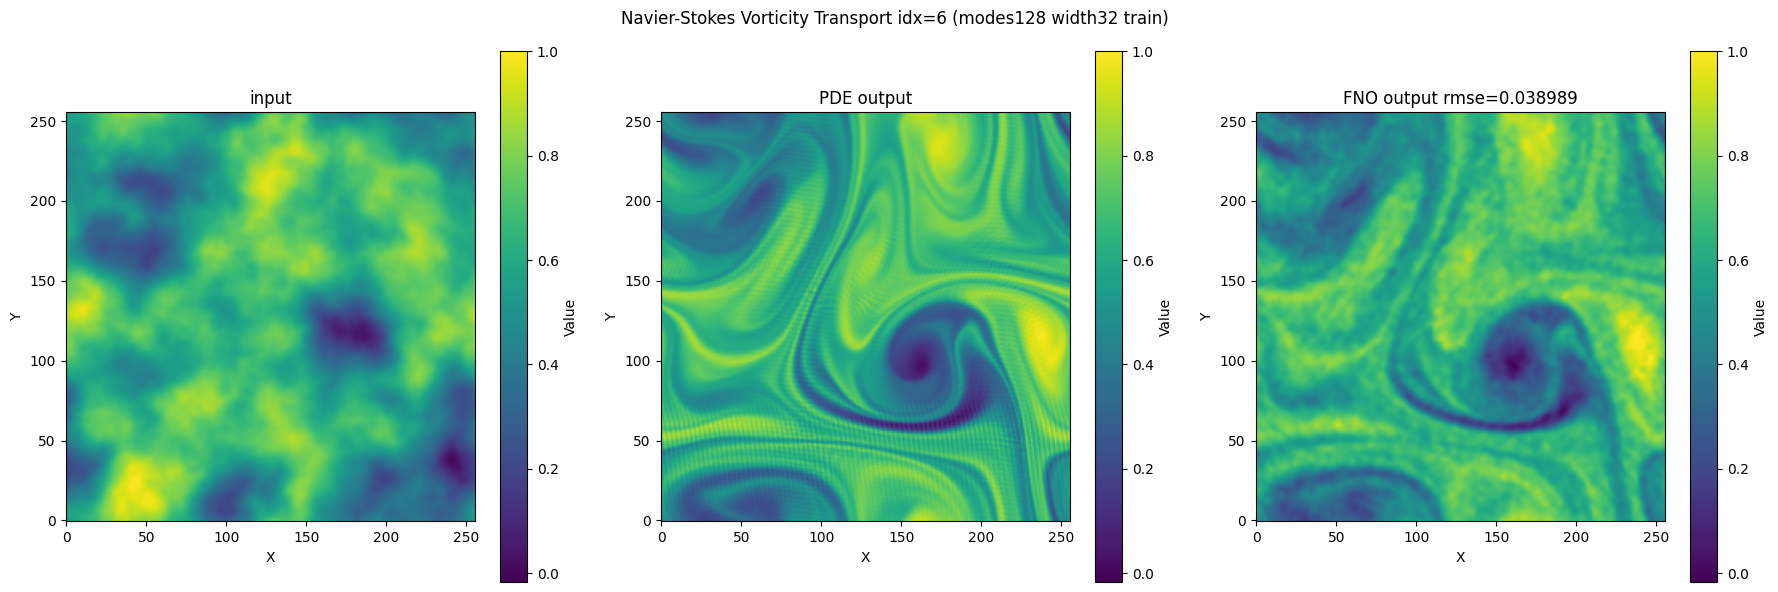

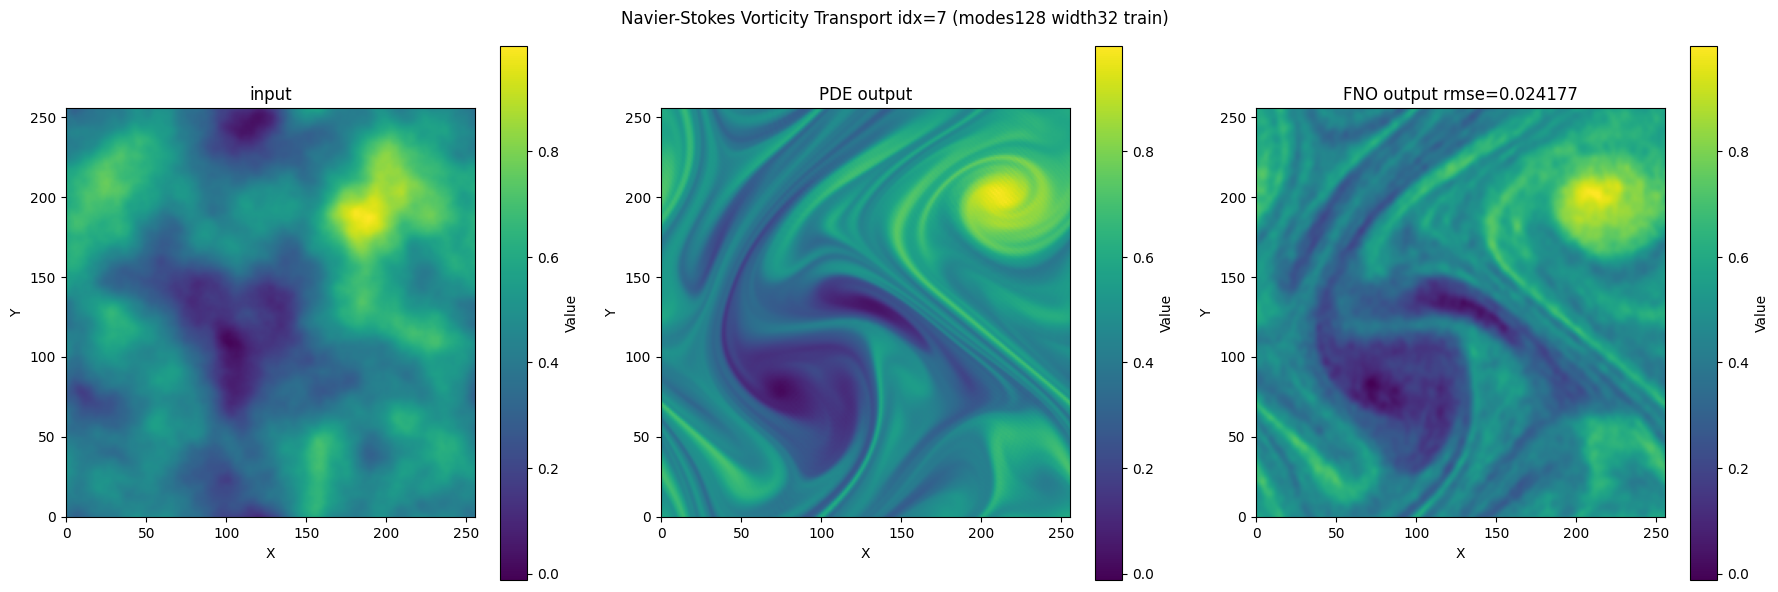

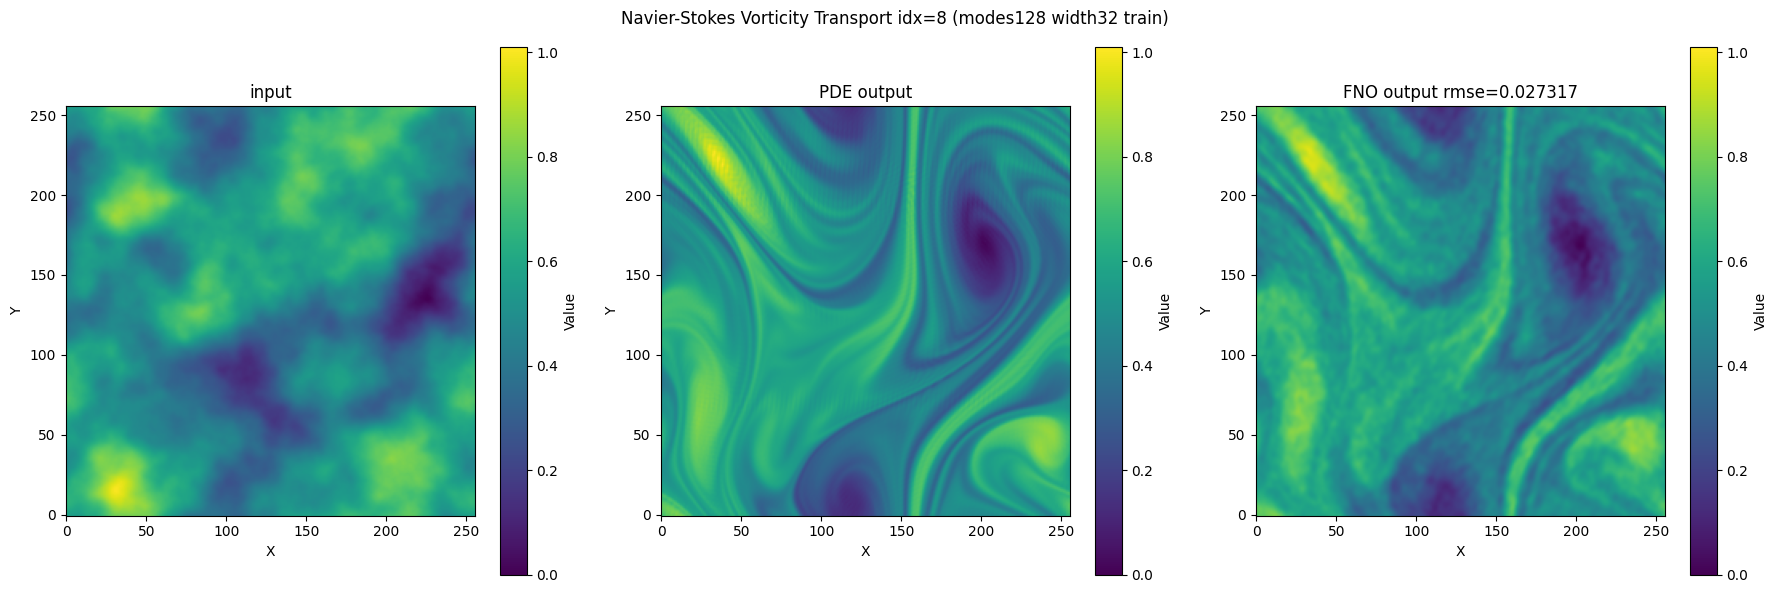

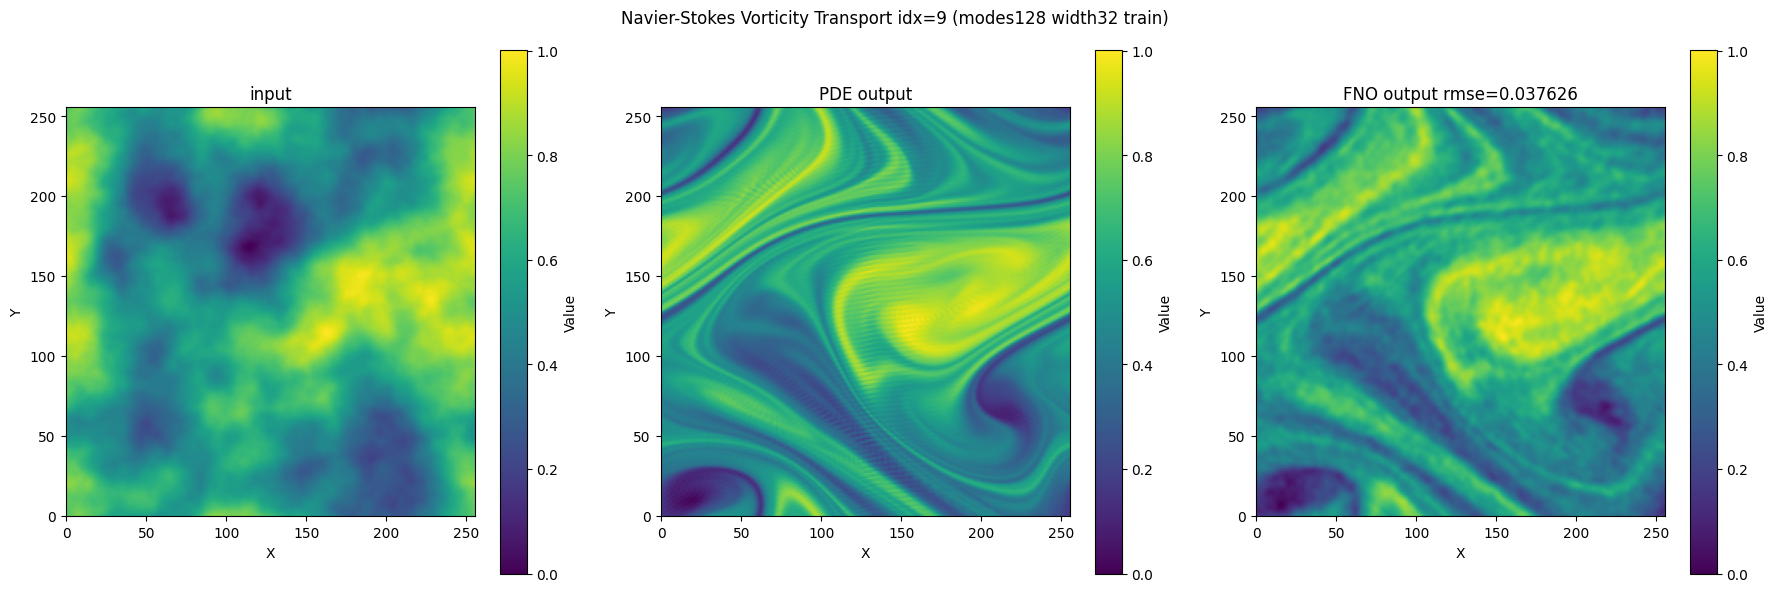

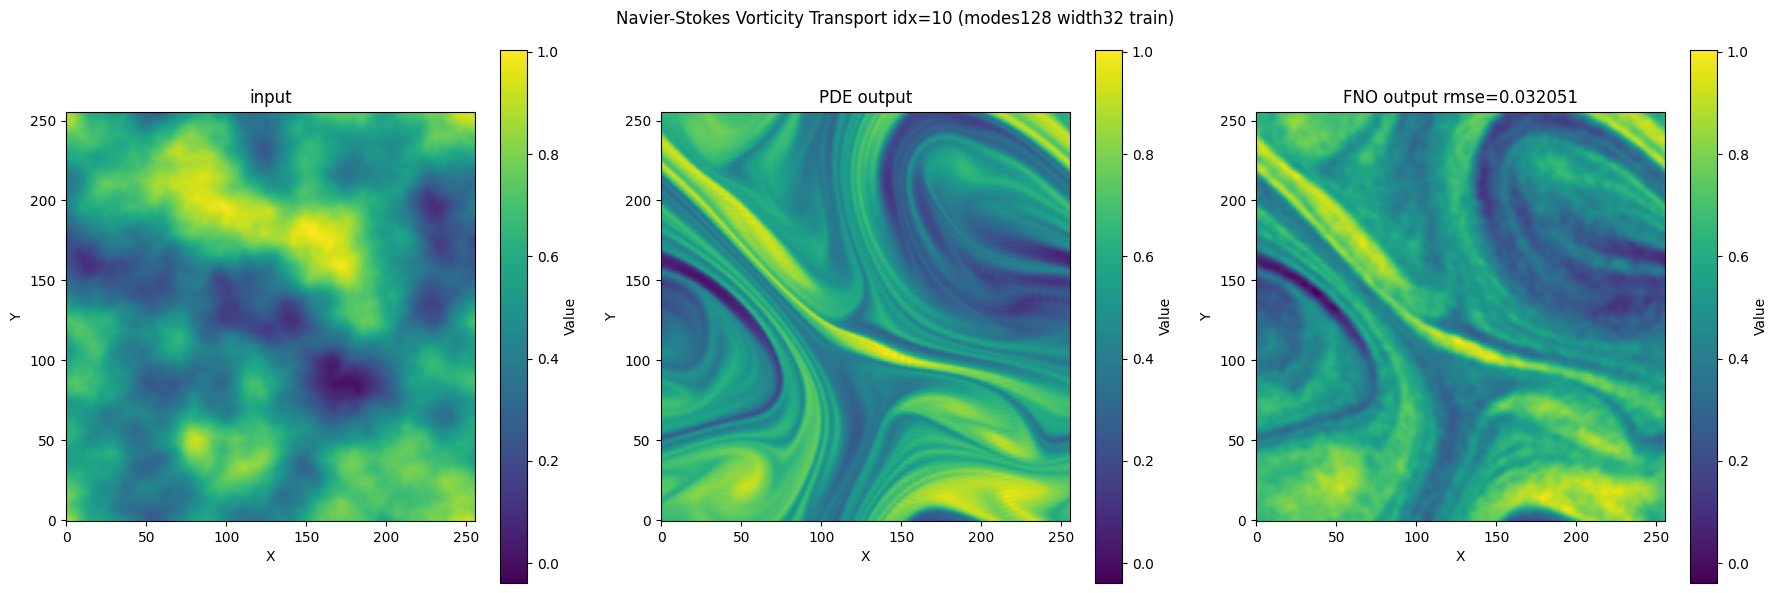

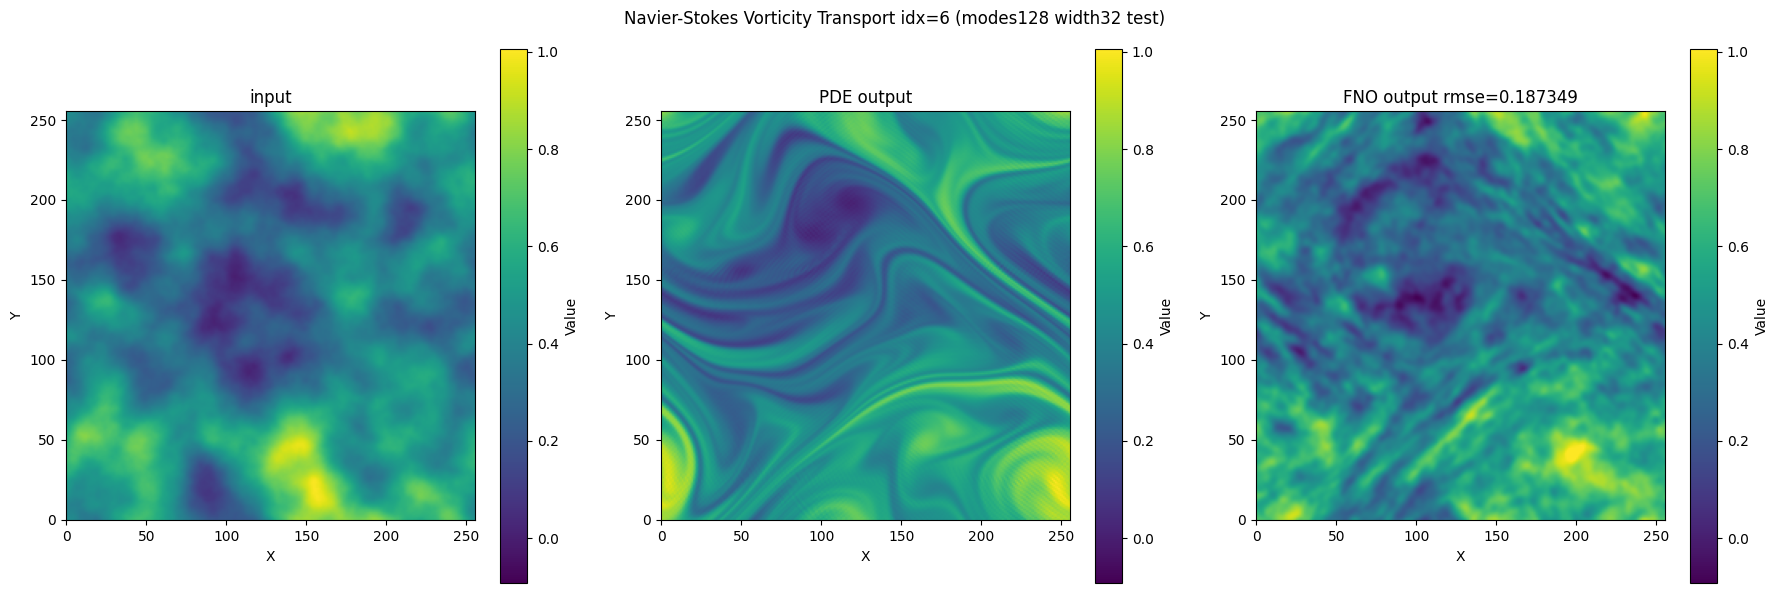

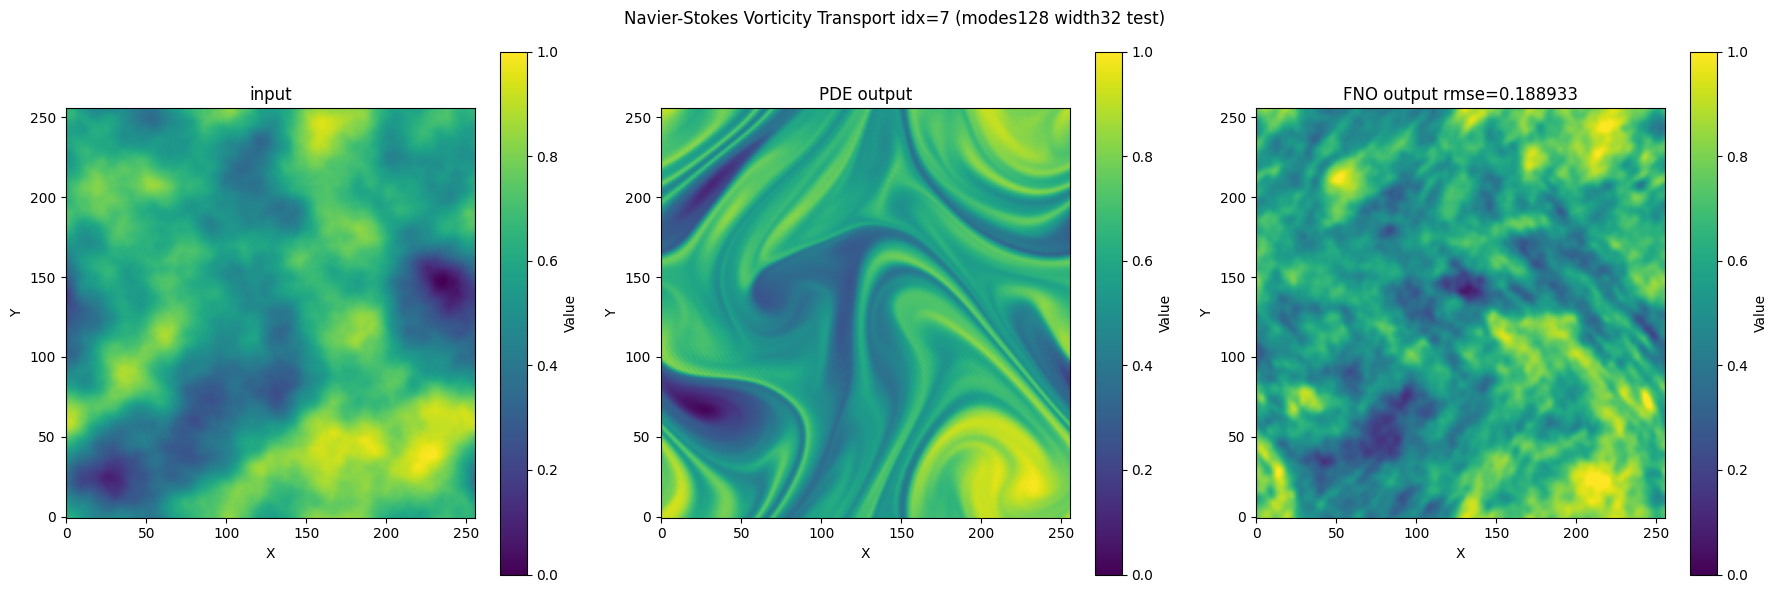

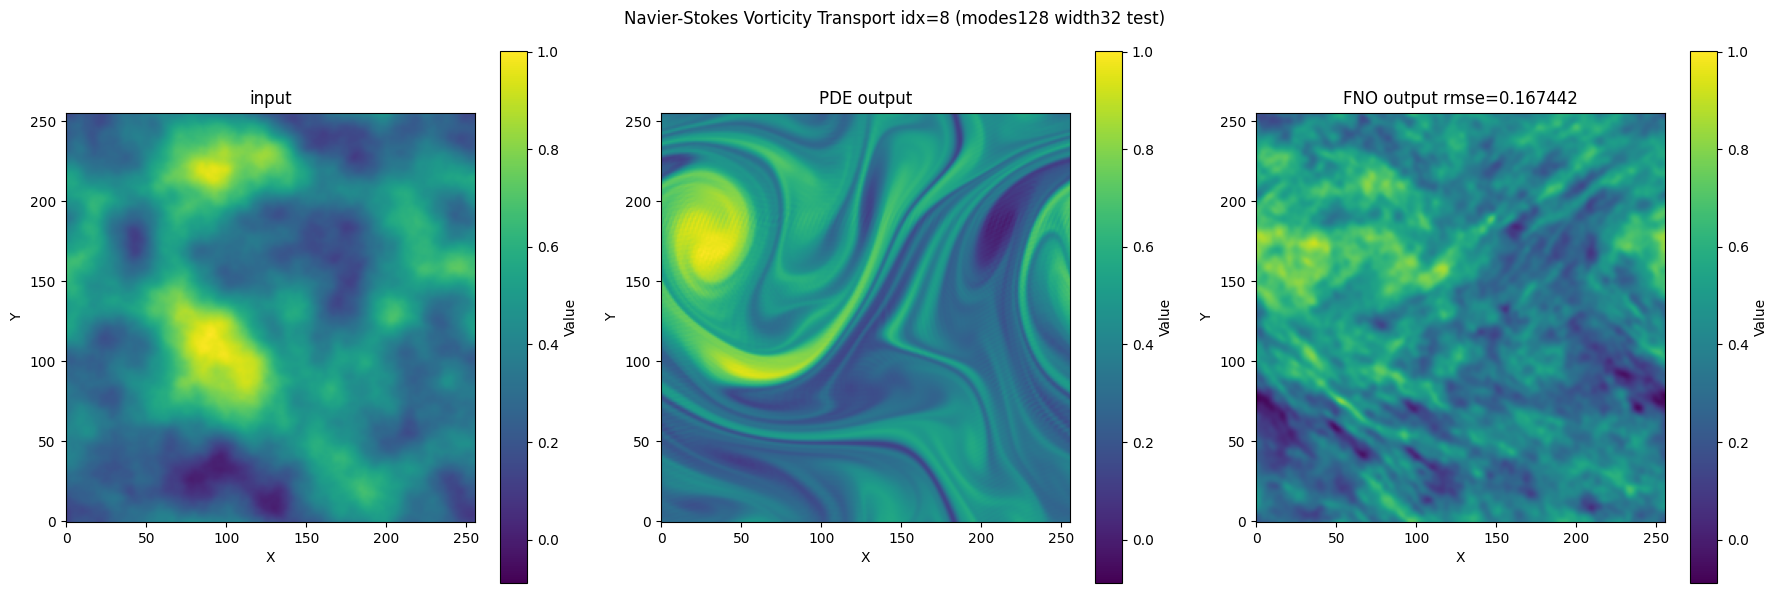

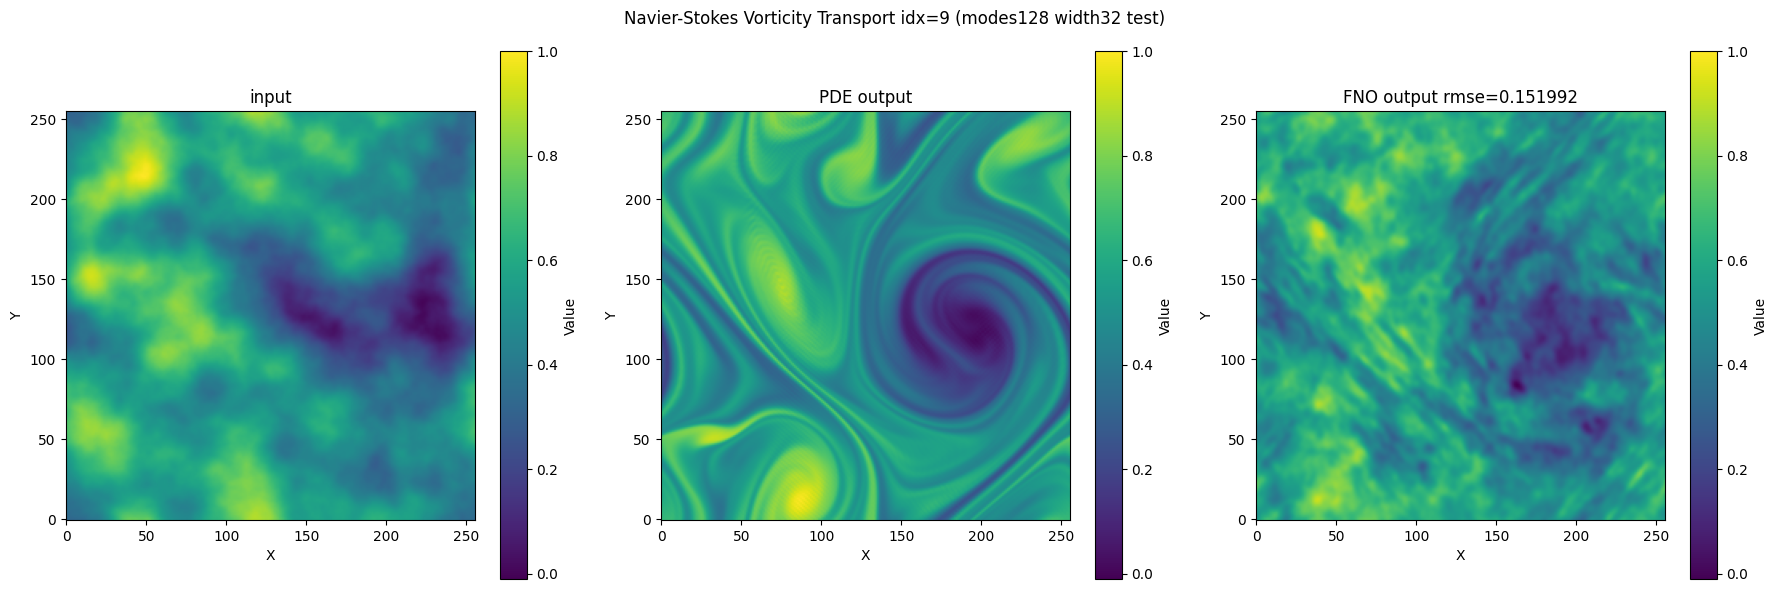

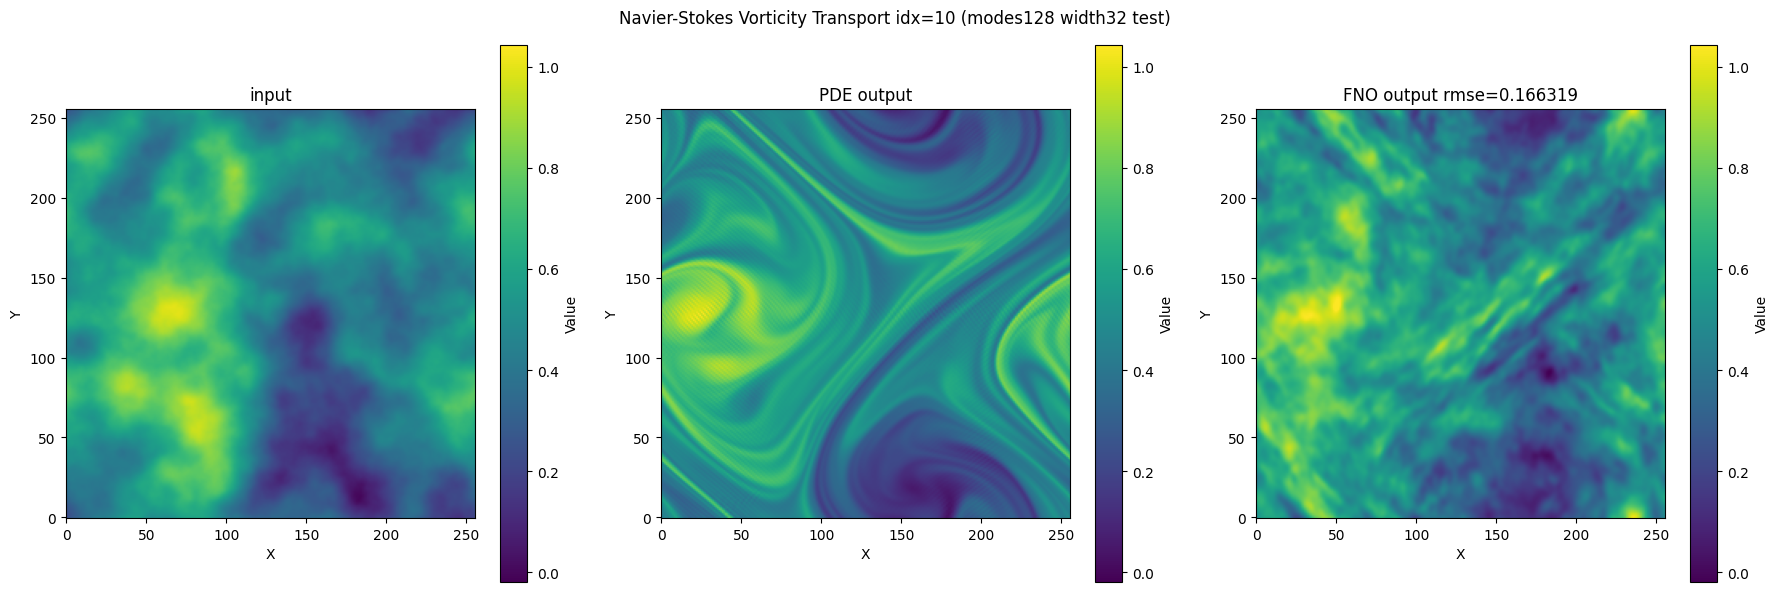

In [3]:
import numpy as np

with torch.no_grad():
    for idx in range(5,10):
        input_ = data_train["x"][idx]
        PDE_output = data_train["y"][idx]
        FNO_output = model_instance(input_.unsqueeze(0).unsqueeze(-1)).squeeze(0).squeeze(-1)
        plot_dual_heatmaps(input_, PDE_output, FNO_output, title1='input', title2='PDE output', title3='FNO output', idx=idx+1, text="modes128 width32 train")
    for idx in range(5,10):
        input_ = data_test["x"][idx]
        PDE_output = data_test["y"][idx]
        FNO_output = model_instance(input_.unsqueeze(0).unsqueeze(-1)).squeeze(0).squeeze(-1)
        plot_dual_heatmaps(input_, PDE_output, FNO_output, title1='input', title2='PDE output', title3='FNO output', idx=idx+1, text="modes128 width32 test")